### Movie Recommendation System

#### Overview
This project implements a **Content-Based Movie Recommendation System** using the TMDB 5000 Movies dataset. It uses Natural Language Processing (NLP) to analyze movie metadata (overviews, taglines, and genres) and suggest the most similar movies to a user's selection.

#### Features
*   **Data Preprocessing:** Cleans and handles missing values in the TMDB dataset.
*   **NLP Pipeline:** Implements a text cleaning pipeline including lowercasing, punctuation removal, and **WordNet Lemmatization**.
*   **Vectorization:** Utilizes **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert text data into numerical vectors, capturing the importance of specific keywords.
*   **Similarity Engine:** Uses **Cosine Similarity** to calculate mathematical distance between movie vectors to find the top 10 closest matches.
*   **Exportable Model:** Saves the processed data and similarity components using `pickle` for easy integration into web applications like Streamlit.

#### Tech Stack
*   **Language:** Python
*   **Libraries:** Pandas, NumPy, NLTK, Scikit-learn, Matplotlib, Seaborn
*   **Tools:** Jupyter Notebook / Google Colab

#### How to Use
1.  Run the notebook to generate the `.pkl` files.
2.  Use the `recommend('Movie Title')` function to get suggestions.
3.  (Optional) Load the pickle files into a Streamlit app for a GUI experience.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('movies_metadata.csv')
df

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45461,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0


In [ ]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [ ]:
df.isnull().sum()

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [ ]:
df.duplicated().sum()   # 13 rows

np.int64(13)

In [ ]:
df = df.drop_duplicates().reset_index(drop = True)   # after rows removal index becomes uneven so reset_index() makes it even and creates extra column of sequential index
# by drop = True -> old index is discarded

In [ ]:
df

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45448,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45449,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45450,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45451,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0


In [ ]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45453 entries, 0 to 45452
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45453 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45453 non-null  object 
 3   genres                 45453 non-null  object 
 4   homepage               7780 non-null   object 
 5   id                     45453 non-null  object 
 6   imdb_id                45436 non-null  object 
 7   original_language      45442 non-null  object 
 8   original_title         45453 non-null  object 
 9   overview               44499 non-null  object 
 10  popularity             45448 non-null  object 
 11  poster_path            45067 non-null  object 
 12  production_companies   45450 non-null  object 
 13  production_countries   45450 non-null  object 
 14  release_date           45366 non-null  object 
 15  re

In [ ]:
df = df[['title','overview','tagline','genres','vote_average','popularity']]

In [ ]:
df

,title,overview,tagline,genres,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",NaN,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just When His World Is Back To Normal... He's ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,Rising and falling between a man and woman,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,NaN,"[{'id': 18, 'name': 'Drama'}]",9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...",A deadly game of wits.,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",NaN,[],0.0,0.003503


In [ ]:
df.isnull().sum()

,0
title,6
overview,954
tagline,25045
genres,0
vote_average,6
popularity,5


In [ ]:
# if title is missing so nothing works so remove them which are null
df = df.dropna(subset=['title'])

In [ ]:
# overview is text so we fill there null values by empty space
df['overview'] = df['overview'].fillna('')

In [ ]:
df['genres'][0]   # df.iloc[0]['genres]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [ ]:
# we take the name using ast.literal_eval()
import ast
df['genres'] = df['genres'].apply(lambda x: " ".join([i['name'] for i in ast.literal_eval(x)]))

In [ ]:
df

,title,overview,tagline,genres,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",NaN,Animation Comedy Family,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,Adventure Fantasy Family,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,Romance Comedy,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,Comedy Drama Romance,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just When His World Is Back To Normal... He's ...,Comedy,5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,Rising and falling between a man and woman,Drama Family,4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,NaN,Drama,9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...",A deadly game of wits.,Action Drama Thriller,3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",NaN,,0.0,0.003503


In [ ]:
# when there is so many null values then either leave them column and if it is important than fill those values by empty space
df['tagline']= df['tagline'].fillna(" ")

In [ ]:
# df = df.drop(['taglined'],axis=1) by mistake new column was created

In [ ]:
df['tagline'].isnull().sum()

np.int64(0)

In [ ]:
df.isnull().sum()  # all of dont hav missing values

,0
title,0
overview,0
tagline,0
genres,0
vote_average,0
popularity,0


#### we are combining these three column so we can vectorise them simultaneously because one single column usually does not contain enough information about a movie. vectorization measures the similiarity of your column mathematically and vetor is simply list of number and then compare similiarity by cosine similiarity or euclidian distance or by dot product.


| Movie        | Vector       |
| ------------ | ------------ |
| Interstellar | [1, 0, 3, 2] |
| Gravity      | [1, 0, 2, 1] |
| Titanic      | [0, 4, 0, 0] |


In [ ]:
df['tags'] = df['overview'] + df['tagline'] + df['genres']

In [ ]:
df

,title,overview,tagline,genres,vote_average,popularity,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",,Animation Comedy Family,7.7,21.946943,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,Adventure Fantasy Family,6.9,17.015539,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,Romance Comedy,6.5,11.7129,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,Comedy Drama Romance,6.1,3.859495,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just When His World Is Back To Normal... He's ...,Comedy,5.7,8.387519,Just when George Banks has recovered from his ...
...,...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,Rising and falling between a man and woman,Drama Family,4.0,0.072051,Rising and falling between a man and woman.Ris...
45449,Century of Birthing,An artist struggles to finish his work while a...,,Drama,9.0,0.178241,An artist struggles to finish his work while a...
45450,Betrayal,"When one of her hits goes wrong, a professiona...",A deadly game of wits.,Action Drama Thriller,3.8,0.903007,"When one of her hits goes wrong, a professiona..."
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",,,0.0,0.003503,"In a small town live two brothers, one a minis..."


In [ ]:
df['tags'][0]

"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. Animation Comedy Family"

### we will remove something that is written in tags value because those are not adding any role to the vectorization
1. Punctuation
2. and, an ,the, dash , when, to ,or. something lije this stopping words are removed

## there are two concept of NLP which is used but we are using lemmatization.
1. Lemmatization
2. Stemming

These are very common techniques in NLP (Natural Language Processing).

Both are used to reduce words to their base/root form so that similar words are treated as the same word.
example : ending -> end

## Lemmatization
Lemmatization converts words into their actual dictionary/base form (called lemma).

| Original Word | Lemmatized Word |
| :--- | :--- |
| playing | play |
| better | good |
| studies | study |
| running | run |

## Stemming

How stemming works

It chops off endings like:

1. ing
2. ed
3. ly
4. s

Very fast but less accurate.
example: studies -> studi

A Regular Expression (Regex) is a special pattern used to:

* search text
* match text
* extract text
* replace text

It helps us work with strings efficiently.

We use regex for:

* text cleaning
* validation
* pattern matching
* data extraction
* NLP preprocessing

| Symbol | Meaning        |
| ------ | -------------- |
| `.`    | Any character  |
| `\d`   | Digit (0-9)    |
| `\D`   | Non-digit      |
| `\w`   | Word character |
| `\s`   | Space          |
| `+`    | One or more    |
| `*`    | Zero or more   |
| `^`    | Starts with    |
| `$`    | Ends with      |



In [ ]:
# import re

# text = "My age is 21 and my score is 95"

# print(re.findall(r'\d+', text))

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re   # regular expression -> used for repetative task

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Create objects for stopwords and lemmatization
stop_word = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def text_cleaning(text):
  # convert all text to lower case
  text = text.lower()
  # remove puntuation
  text = re.sub(r'[^a-zA-Z\s]','',text)
  # tokenisation
  text = text.split()
  # remove stop_words
  words = [word for word in text if word not in stop_word]
  # lemmetizing
  words = [lemmatizer.lemmatize(word) for word in words]

  # at the final we have to return list complete string as intially it was

  return " ".join(words)


In [ ]:
# apply this fucntion to the tags
df['tags'] = df['tags'].apply(text_cleaning)

In [ ]:
df['tags'][0]

'led woody andys toy live happily room andys birthday brings buzz lightyear onto scene afraid losing place andys heart woody plot buzz circumstance separate buzz woody owner duo eventually learns put aside difference animation comedy family'

## Vectorization

In [ ]:
# we have removed the some rows then there might be index problem
df  = df.reset_index(drop=True)   # by drop=True -> means old unarranged index is removed and keep new index

 #NOTE

 #### We create a mapping between the movie titles and their indices for a very practical reason: Efficient Lookup.

#### When you eventually want to recommend movies, you will likely start with a movie title (e.g., 'Toy Story'). However, the mathematical similarity matrix we are about to build works with numerical indices, not text.

#### By creating a Series where the title is the index, we can instantly find that 'Toy Story' is at index 0. This allows us to fetch the similarity scores for that specific row without searching through the entire dataset every time

In [ ]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()
indices

,0
title,
Toy Story,0
Jumanji,1
Grumpier Old Men,2
Waiting to Exhale,3
Father of the Bride Part II,4
...,...
Subdue,45442
Century of Birthing,45443
Betrayal,45444


There are three method for tokenization
* 1. OneHotEndcoding
      * in Onehotendcoding for every word token is created and that are list so there are list of list (there is one main list storing all list)
* 2. Bag of Words
      * Bag of Words (BoW) is a technique in NLP used to convert text into numbers so machine learning models can understand it.

      * It represents text using:
          * words
         * and their frequencies/counts

      * BoW ignores:
          * grammar
          * word order
          * sentence structure

          * It only cares about:
              * “Which words appear and how many times?”
              * That’s why it is called a Bag of words.

          * Example:
              * Let we have two sentences:
                  * 1. "I love Python"
                  * 2. "I love NLP"

              * STEP-1:
                * Create Vocabulary:
                  * Collect all unique words:
                    * [I, love, Python, NLP]
                    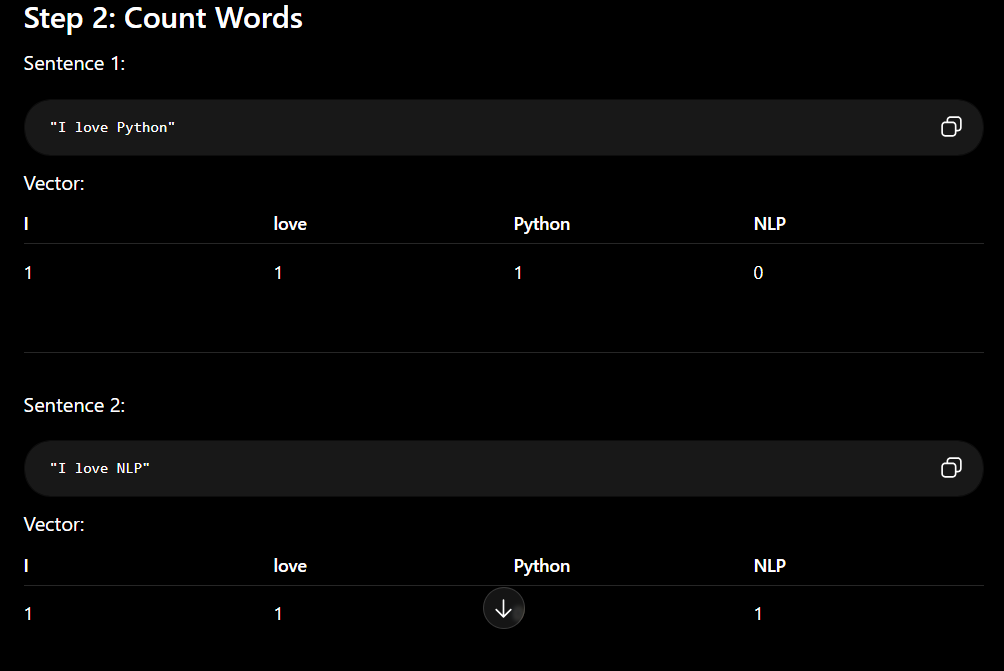

                    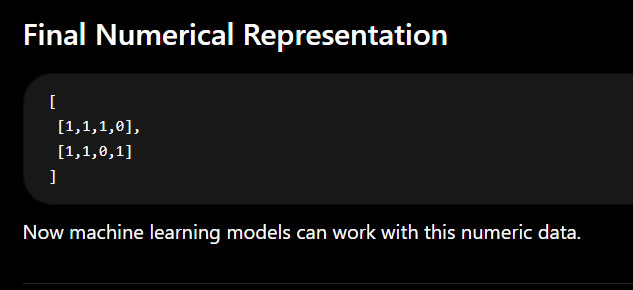

                    * DisAdvantages:
                      * Sparsity : A property of a dataset or matrix where most of the elements or values are zero.


In [ ]:
# so we use TFIDF for the tokenization
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features = 50000, ngram_range=(1,2), stop_words = 'english')

In [ ]:
tfidf_matrix = tfidf.fit_transform(df['tags'])

In [ ]:
tfidf_matrix.shape

(45447, 50000)

In [ ]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1467562 stored elements and shape (45447, 50000)>

## Now checking for similiarities for recommendation

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def recommend(title, n=10):   # 10 movies will be recommended
  if title not in indices:
    return ["Movie is not found!!"]   # here we are returning as list because output is multiple movies

  idx = indices[title]   # here is indices[title] no inverted commas because accessing title as variable of fucntion

  # comaparing one movie with all movies and then convert 2D ouput to 1D using .flatten()
  sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

  similiar_idx = sim_scores.argsort()[::-1][1:n+1]
  # normal sorting is done on the basis of values but argsort is based on index and from last find 10 movies

  return df['title'].iloc[similiar_idx]



In [ ]:
recommend('Avenger')

,title
25089,Hit by Lightning
12061,The Hunting Party
5054,Hopscotch
34012,Sharpshooter
7871,The Escapist
41886,Dexter's Laboratory: Ego Trip
584,Tough and Deadly
4367,D.O.A.
30409,"The Man Nobody Knew: In Search of My Father, C..."
23383,The Last Time I Saw Archie


## Now for making UI we have to extract pickle file

In [ ]:
import pickle

pickle.dump(df, open('movie_list.pkl', 'wb'))

pickle.dump(tfidf_matrix, open('tfidf_matrix.pkl', 'wb'))

pickle.dump(indices, open('indices.pkl', 'wb'))

pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

pickle.dump(cosine_similarity, open('cosine_similarity.pkl', 'wb'))
